# YOLO with Real COCO Data 


## Detection in one picture

```text
Street image
┌──────────────────────────────────────────────┐
│  ┌──────────┐                                │
│  │ person   │ 0.91                            │
│  └──────────┘                                │
│                         ┌──────────────────┐ │
│                         │       bus        │ │
│                         │       0.88       │ │
│                         └──────────────────┘ │
└──────────────────────────────────────────────┘

image -> separate object boxes -> class + confidence
```

- A detection gives a class, a box, and a confidence score.
- One image can have many detections.

## 1. Install Ultralytics

Ultralytics gives a simple Python interface for a PyTorch YOLO model. Run this cell once. If Jupyter asks for a restart, restart the kernel and continue from the next cell.

In [2]:
# WHAT: Install the YOLO library used in this lab.
# WHY: It provides ready-to-use PyTorch YOLO training and prediction tools.
# OUTPUT: The package is available for import in the next cell.

%pip install -q "ultralytics==8.4.132"

Note: you may need to restart the kernel to use updated packages.


## 2. Import the required libraries

`torch` is the deep-learning framework. `YOLO` is the simple model interface. `matplotlib` shows images, and `pandas` shows a small results table.

In [3]:
# WHAT: Import libraries and choose the best available device.

# WHY: Use NVIDIA CUDA, Apple Silicon MPS, or CPU automatically.

# OUTPUT: Library versions, selected device, and output folder.

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import ultralytics
from PIL import Image
from ultralytics import YOLO, settings

if torch.cuda.is_available():
    DEVICE = "cuda"  # NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"   # Apple Silicon GPU
else:
    DEVICE = "cpu"

OUTPUT_FOLDER = Path.cwd() / "yolo_real_data_output"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
print("Device:", DEVICE)
print("Output folder:", OUTPUT_FOLDER)

PyTorch: 2.13.0
Ultralytics: 8.4.132
CUDA available: False
MPS available: True
Device: mps
Output folder: /Users/suvom/Desktop/LogicMojo/LogicMojo-AI-April-2026/6_object_detection/yolo_real_data_output


## 3. Load a pretrained YOLO model

```python
model = YOLO("yolo26n.pt")
```

- `YOLO` means **You Only Look Once**.
- `n` means **nano**, a small model.
- `.pt` is a PyTorch weights file.
- **Pretrained** means the model already learned useful visual patterns from many images.

### Diagram: the YOLO pipeline

```text
Input image
     │
     ▼
BACKBONE
finds edges, shapes and object features
     │
     ▼
NECK
mixes detailed and wide-view features
     │
     ▼
HEAD
predicts boxes, object scores and classes
     │
     ▼
confidence filter + NMS
     │
     ▼
final detections
```

- Backbone finds patterns.
- Neck mixes feature information from different image sizes.
- Head makes the final predictions.

In [4]:
# WHAT: Load a small pretrained YOLO model.
# WHY: Pretrained weights can detect real objects before a new training run.
# OUTPUT: Model information and confirmation that the inside is a PyTorch module.

model = YOLO("yolo26n.pt")

print("Task:", model.task)
print("PyTorch model?", isinstance(model.model, torch.nn.Module))

Task: detect
PyTorch model? True


## 4. Detect objects in one real image

The `predict` call runs the full YOLO pipeline:

```text
image -> features -> boxes and class scores -> confidence filter -> final detections
```

`conf=0.35` keeps detections with confidence at least 0.35.

In [5]:
# WHAT: Run the pretrained model on a real street image.
# WHY: This gives an immediate example of object detection on real data.
# OUTPUT: Final detections for people and a bus.

result = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.35,
    imgsz=320,
    device=DEVICE,
    verbose=False,
)[0]

print("Detections:", len(result.boxes))

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Detections: 5


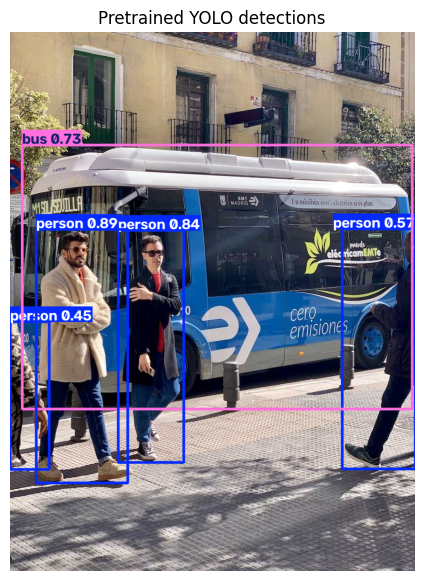

In [6]:
# WHAT: Display YOLO's built-in annotated image.
# WHY: The image makes boxes, labels, and confidence values easy to check.
# OUTPUT: A street image with final YOLO detections.

plt.figure(figsize=(10, 7))
plt.imshow(result.plot()[:, :, ::-1])
plt.title("Pretrained YOLO detections")
plt.axis("off")
plt.show()

## 5. Read the returned boxes

Each final detection has:

```text
xyxy -> [x1, y1, x2, y2] box corners
conf -> confidence score
cls  -> numeric class ID
names -> readable class name
```

These values are PyTorch tensors. The loop below only changes them into a small table for reading.

### Diagram: one bounding box

```text
       (x1, y1) ┌───────────────┐
                │    object     │
                │       ●       │  ● = centre
                │               │
                └───────────────┘ (x2, y2)

xyxy = [x1, y1, x2, y2]
```

- `x1, y1` is the top-left corner.
- `x2, y2` is the bottom-right corner.

In [7]:
# WHAT: Put the final YOLO predictions into a readable table.
# WHY: Each row connects one box with a class name and confidence score.
# OUTPUT: A table of detected objects and their box corners.

rows = []

for box, score, class_id in zip(result.boxes.xyxy.cpu(), result.boxes.conf.cpu(), result.boxes.cls.cpu()):
    rows.append({
        "class": result.names[int(class_id)],
        "confidence": round(float(score), 3),
        "x1": round(float(box[0]), 1),
        "y1": round(float(box[1]), 1),
        "x2": round(float(box[2]), 1),
        "y2": round(float(box[3]), 1),
    })

pd.DataFrame(rows)

,class,confidence,x1,y1,x2,y2
0,person,0.885,52.9,395.6,235.2,903.6
1,person,0.844,216.2,397.3,347.3,862.2
2,bus,0.729,25.0,226.0,804.8,755.8
3,person,0.566,664.6,394.7,810.0,875.2
4,person,0.447,0.8,580.9,78.5,876.6


## 6. COCO8: a tiny real dataset

**COCO** means **Common Objects in Context**. COCO8 contains eight real images:

| Split | Images | Labelled objects |
|---|---:|---:|
| Train | 4 | 13 |
| Validation | 4 | 17 |

COCO8 is useful for understanding the workflow. It is too small to prove that a model is ready for real-world use.

### Diagram: multi-scale grids

```text
Fine grid                 Medium grid               Coarse grid
small object detail       medium object detail      large object context

┌─┬─┬─┬─┬─┐                ┌──┬──┬──┐               ┌────┬────┐
│ │●│ │ │ │                │  │ ●│  │               │    │ ●  │
├─┼─┼─┼─┼─┤                ├──┼──┼──┤               ├────┼────┤
│ │ │ │ │ │                │  │  │  │               │    │    │
└─┴─┴─┴─┴─┘                └──┴──┴──┘               └────┴────┘

bolt                       tool                       large box
```

YOLO collects candidates from all grids, removes weak ones, and removes duplicates.

## 7. Train for three short epochs

This call uses built-in code for image reading, labels, batches, losses, backpropagation, validation, checkpoint saving, confidence filtering, and duplicate removal.

```text
4 train images + batch size 4 = 1 batch in one epoch
3 epochs = about 3 model-update steps
```

This is a workflow demonstration, not production training.

### Diagram: real-data training flow

```text
COCO8 images + labels
          │
          ▼
pretrained YOLO weights
          │
          ▼
training batches
          │
          ▼
box loss + class loss + L1 loss
          │
          ▼
PyTorch updates weights
          │
          ▼
validation images -> metrics and predictions
```

The library runs these steps internally when `training_model.train(...)` is called.

In [8]:
# WHAT: Start a small real-data YOLO training run.
# WHY: It shows how a pretrained PyTorch model learns from labelled images.
# OUTPUT: Training losses, validation metrics, and saved best/last weight files.

training_model = YOLO("yolo26n.pt")

training_metrics = training_model.train(
    data="coco8.yaml",
    epochs=3,
    imgsz=320,
    batch=4,
    device=DEVICE,
    workers=0,
    project=str(OUTPUT_FOLDER / "runs"),
    name="coco8_demo",
    exist_ok=True,
    plots=False,
    seed=42,
    verbose=False,
)

Ultralytics 8.4.132 🚀 Python-3.13.5 torch-2.13.0 MPS (Apple M2 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coco8_demo, nbs=64, nms=False, opset=None, optimize=False, optimize

/Users/suvom/anaconda3/envs/ai_ecomm/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        1/3     0.413G      1.711      3.784    0.02092         26        320: 100% ━━━━━━━━━━━━ 1/1 13.3s/it 13.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8s/it 1.8s
                   all          4         17      0.714      0.633      0.715      0.451

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
        2/3     0.499G      1.407      4.586    0.02813         17        320: 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s


/Users/suvom/anaconda3/envs/ai_ecomm/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all          4         17      0.714      0.633      0.715      0.451

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
        3/3     0.522G      1.438      3.615    0.03576         16        320: 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s


/Users/suvom/anaconda3/envs/ai_ecomm/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all          4         17      0.714      0.633      0.715      0.451

3 epochs completed in 0.007 hours.
Optimizer stripped from /Users/suvom/Desktop/LogicMojo/LogicMojo-AI-April-2026/6_object_detection/yolo_real_data_output/runs/coco8_demo/weights/last.pt, 5.5MB
Optimizer stripped from /Users/suvom/Desktop/LogicMojo/LogicMojo-AI-April-2026/6_object_detection/yolo_real_data_output/runs/coco8_demo/weights/best.pt, 5.5MB

Validating /Users/suvom/Desktop/LogicMojo/LogicMojo-AI-April-2026/6_object_detection/yolo_real_data_output/runs/coco8_demo/weights/best.pt...
Ultralytics 8.4.132 🚀 Python-3.13.5 torch-2.13.0 MPS (Apple M2 Pro)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5s/it 1.5s
             

### Reading the training log

| Value | Meaning |
|---|---|
| `box_loss` | Error in box location and size |
| `cls_loss` | Error in class prediction |
| `l1_loss` | Absolute box-coordinate error |
| `mAP50` | Detection quality at IoU 0.50 |
| `mAP50-95` | Stricter detection-quality value |

The optimizer is selected automatically by Ultralytics. In the verified run it selected **AdamW**.

## 8. Inspect real images and labels

The training call downloads COCO8 automatically. The next cells show the real validation images and the label text for one image.

One label line has this form:

```text
class_id  centre_x  centre_y  width  height
```

The four box values are normalized between 0 and 1.

In [9]:
# WHAT: Locate the COCO8 validation images downloaded by the training call.
# WHY: The files show the real images used in this small detection example.
# OUTPUT: The dataset path and four validation filenames.

dataset_folder = Path(settings["datasets_dir"]) / "coco8"
validation_images = sorted((dataset_folder / "images" / "val").glob("*.jpg"))

print("Dataset folder:", dataset_folder)
print("Validation images:", [image_path.name for image_path in validation_images])

Dataset folder: /Users/suvom/Desktop/POC/datasets/coco8
Validation images: ['000000000036.jpg', '000000000042.jpg', '000000000049.jpg', '000000000061.jpg']


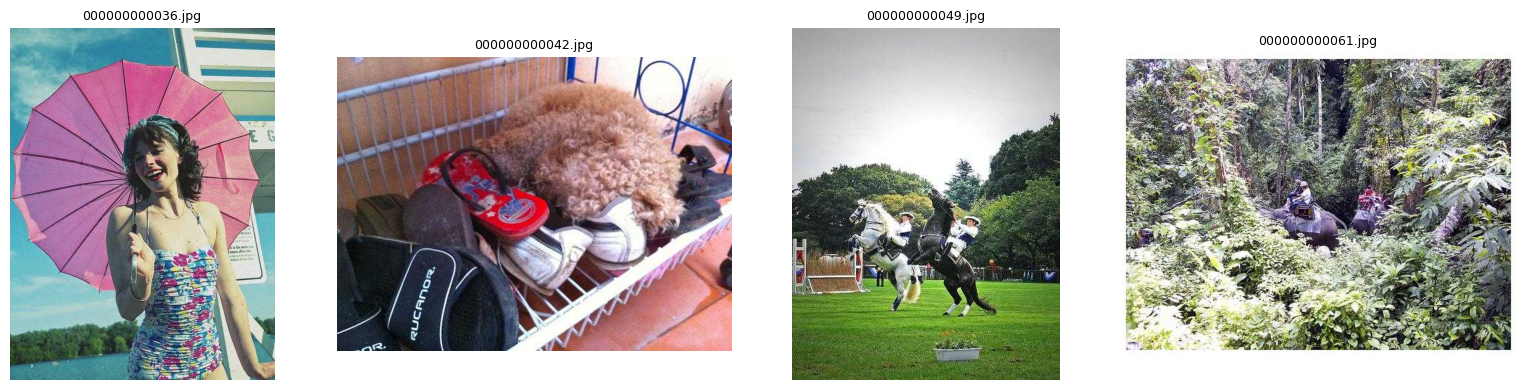

In [10]:
# WHAT: Display all real COCO8 validation images.
# WHY: Real images contain different backgrounds, object sizes, and object positions.
# OUTPUT: Four real images from the validation set.

fig, axes = plt.subplots(1, len(validation_images), figsize=(16, 4))

for axis, image_path in zip(axes, validation_images):
    axis.imshow(Image.open(image_path).convert("RGB"))
    axis.set_title(image_path.name, fontsize=9)
    axis.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# WHAT: Read the label file that matches the first validation image.
# WHY: It connects one real image with the YOLO class-and-box format.
# OUTPUT: Raw label lines and the class name of the first object.

sample_image = validation_images[0]
sample_label = dataset_folder / "labels" / "val" / f"{sample_image.stem}.txt"
label_lines = sample_label.read_text().strip().splitlines()

print("Image:", sample_image.name)
print("Label lines:")
for line in label_lines[:3]:
    print(line)

first_label = [float(value) for value in label_lines[0].split()]
print("First class:", model.names[int(first_label[0])])
print("First normalized box:", first_label[1:])

Image: 000000000036.jpg
Label lines:
25 0.475759 0.414523 0.951518 0.672422
0 0.671279 0.617945 0.645759 0.726859
First class: umbrella
First normalized box: [0.475759, 0.414523, 0.951518, 0.672422]


## 9. Predict the validation images

The original pretrained `model` is used here. A three-epoch run on four images is only a short training demonstration, so the pretrained model gives a clearer prediction example.

In [12]:
# WHAT: Predict objects in the real validation images.
# WHY: Object detection should be checked on images not used for the small training split.
# OUTPUT: One YOLO result for each validation image.

validation_results = model.predict(
    source=str(dataset_folder / "images" / "val"),
    conf=0.25,
    imgsz=320,
    device=DEVICE,
    verbose=False,
)

print("Images processed:", len(validation_results))
print("Detections per image:", [len(item.boxes) for item in validation_results])

Images processed: 4
Detections per image: [2, 1, 2, 0]


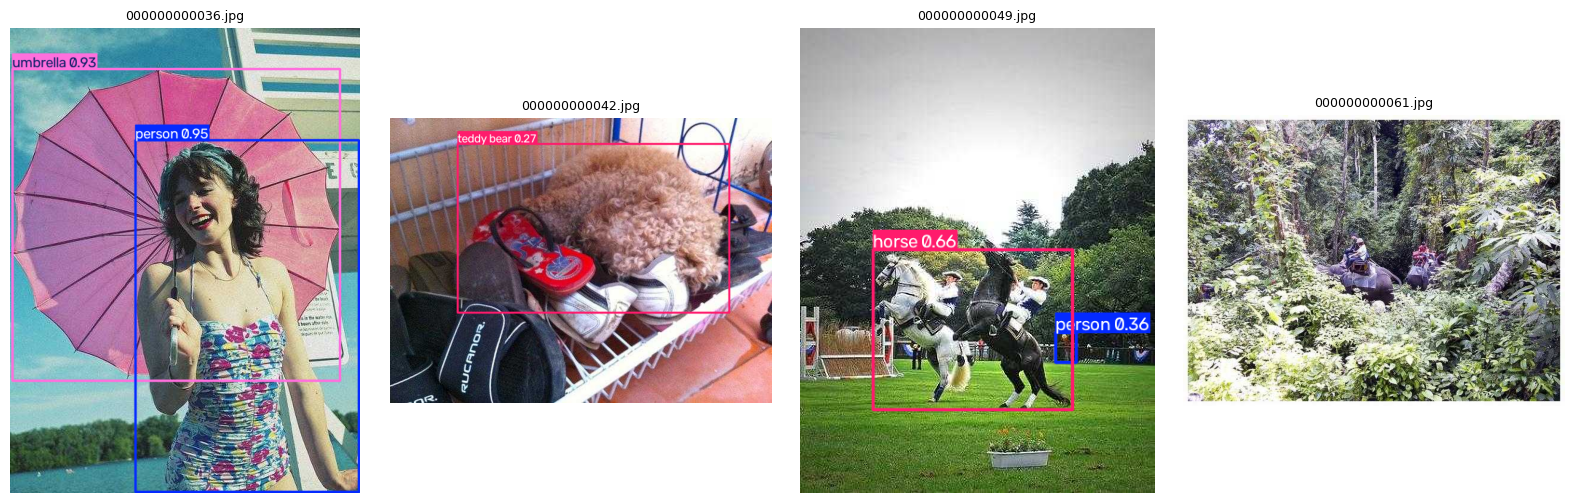

In [13]:
# WHAT: Display built-in YOLO predictions for the validation images.
# WHY: Looking at boxes is important because one metric cannot show every mistake.
# OUTPUT: Four annotated real images.

fig, axes = plt.subplots(1, len(validation_results), figsize=(16, 5))

for axis, item in zip(axes, validation_results):
    axis.imshow(item.plot()[:, :, ::-1])
    axis.set_title(Path(item.path).name, fontsize=9)
    axis.axis("off")

plt.tight_layout()
plt.show()

## 10. Change the confidence threshold

Confidence decides which predictions are kept.

```text
conf = 0.15 -> keep more predictions
conf = 0.70 -> keep fewer, stronger predictions
```

YOLO handles duplicate removal with built-in NMS.

### Diagram: confidence and NMS

```text
candidate boxes
person 0.92
person 0.76   <- overlapping duplicate
bus    0.88
weak   0.18
      │
      ▼
confidence threshold removes weak 0.18
      │
      ▼
NMS removes duplicate person 0.76
      │
      ▼
final: person 0.92, bus 0.88
```

The threshold removes weak guesses. NMS removes repeated boxes for the same object.

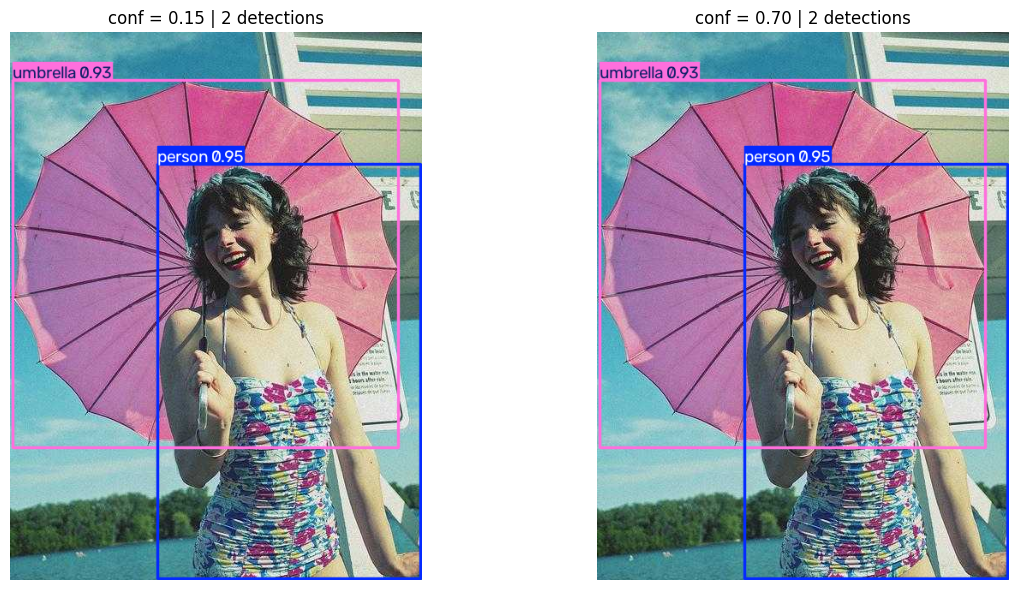

In [14]:
# WHAT: Compare low and high confidence thresholds on the same image.
# WHY: Threshold choice changes the number of final detections.
# OUTPUT: Two annotated images with different numbers of boxes.

low_confidence = model.predict(
    source=str(sample_image), conf=0.15, imgsz=320, device=DEVICE, verbose=False
)[0]

high_confidence = model.predict(
    source=str(sample_image), conf=0.70, imgsz=320, device=DEVICE, verbose=False
)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(low_confidence.plot()[:, :, ::-1])
axes[0].set_title(f"conf = 0.15 | {len(low_confidence.boxes)} detections")
axes[1].imshow(high_confidence.plot()[:, :, ::-1])
axes[1].set_title(f"conf = 0.70 | {len(high_confidence.boxes)} detections")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 11. Key ideas

```text
Object detection = class + box + confidence
YOLO             = one-pass object detector
Backbone         = finds image features
Neck             = mixes features from different sizes
Head             = predicts boxes and classes
Confidence       = removes weak predictions
NMS              = removes duplicate boxes
COCO8            = small real-data workflow sample
```

## Try these changes

1. Change `conf=0.25` to `conf=0.50` for validation predictions.
2. Change `epochs=3` to `epochs=5` and compare the training log.
3. Open another label file and identify its first class and box.

Remember: a larger and more representative dataset is needed before trusting a model in a real application.